
## <h1><center>Clasificación binaria con Keras</center></h1>

## <center>Acerca de los datos </center>

Usaemos el conjunto de datos de 25.000 reseñas de películas de IMDB, etiquetadas por sentimiento (positivo/negativo). Las reseñas se han preprocesado y cada reseña está codificada como una lista de índices de palabras (enteros). Por conveniencia, las palabras se indexan por frecuencia general en el conjunto de datos, de modo que, por ejemplo, el número entero "3" codifica la tercera palabra más frecuente en los datos. Esto permite operaciones de filtrado rápidas como: "considerar sólo las 10.000 palabras más comunes, pero eliminar las 20 primeras palabras más comunes".

<br>

> <small> Nota: <br> Datos extraidos de : https://keras.io/api/datasets/imdb/






## Importamos librerías

In [1]:
from keras.datasets import imdb
from keras import models, layers, optimizers
import numpy as np


## Descargamos los datos de imdb - Keras

In [2]:
(train_data, train_labels), (test_data, test_labels) = imdb.load_data(num_words=10000,index_from=3)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [3]:
# train_data[0]

In [4]:
train_labels[0]

np.int64(1)

### Diccionario de palabras

In [5]:
word_index = imdb.get_word_index()


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 1s 1us/step


In [6]:
word_index

{'fawn': 34701,
 'tsukino': 52006,
 'nunnery': 52007,
 'sonja': 16816,
 'vani': 63951,
 'woods': 1408,
 'spiders': 16115,
 'hanging': 2345,
 'woody': 2289,
 'trawling': 52008,
 "hold's": 52009,
 'comically': 11307,
 'localized': 40830,
 'disobeying': 30568,
 "'royale": 52010,
 "harpo's": 40831,
 'canet': 52011,
 'aileen': 19313,
 'acurately': 52012,
 "diplomat's": 52013,
 'rickman': 25242,
 'arranged': 6746,
 'rumbustious': 52014,
 'familiarness': 52015,
 "spider'": 52016,
 'hahahah': 68804,
 "wood'": 52017,
 'transvestism': 40833,
 "hangin'": 34702,
 'bringing': 2338,
 'seamier': 40834,
 'wooded': 34703,
 'bravora': 52018,
 'grueling': 16817,
 'wooden': 1636,
 'wednesday': 16818,
 "'prix": 52019,
 'altagracia': 34704,
 'circuitry': 52020,
 'crotch': 11585,
 'busybody': 57766,
 "tart'n'tangy": 52021,
 'burgade': 14129,
 'thrace': 52023,
 "tom's": 11038,
 'snuggles': 52025,
 'francesco': 29114,
 'complainers': 52027,
 'templarios': 52125,
 '272': 40835,
 '273': 52028,
 'zaniacs': 52130,

In [7]:
word_index = dict([(value,key) for (key,value) in word_index.items()])
word_index

{34701: 'fawn',
 52006: 'tsukino',
 52007: 'nunnery',
 16816: 'sonja',
 63951: 'vani',
 1408: 'woods',
 16115: 'spiders',
 2345: 'hanging',
 2289: 'woody',
 52008: 'trawling',
 52009: "hold's",
 11307: 'comically',
 40830: 'localized',
 30568: 'disobeying',
 52010: "'royale",
 40831: "harpo's",
 52011: 'canet',
 19313: 'aileen',
 52012: 'acurately',
 52013: "diplomat's",
 25242: 'rickman',
 6746: 'arranged',
 52014: 'rumbustious',
 52015: 'familiarness',
 52016: "spider'",
 68804: 'hahahah',
 52017: "wood'",
 40833: 'transvestism',
 34702: "hangin'",
 2338: 'bringing',
 40834: 'seamier',
 34703: 'wooded',
 52018: 'bravora',
 16817: 'grueling',
 1636: 'wooden',
 16818: 'wednesday',
 52019: "'prix",
 34704: 'altagracia',
 52020: 'circuitry',
 11585: 'crotch',
 57766: 'busybody',
 52021: "tart'n'tangy",
 14129: 'burgade',
 52023: 'thrace',
 11038: "tom's",
 52025: 'snuggles',
 29114: 'francesco',
 52027: 'complainers',
 52125: 'templarios',
 40835: '272',
 52028: '273',
 52130: 'zaniacs',

In [8]:
for x in train_data[0]:
    print(word_index.get(x))

the
as
you
with
out
themselves
powerful
lets
loves
their
becomes
reaching
had
journalist
of
lot
from
anyone
to
have
after
out
atmosphere
never
more
room
and
it
so
heart
shows
to
years
of
every
never
going
and
help
moments
or
of
every
chest
visual
movie
except
her
was
several
of
enough
more
with
is
now
current
film
as
you
of
mine
potentially
unfortunately
of
you
than
him
that
with
out
themselves
her
get
for
was
camp
of
you
movie
sometimes
movie
that
with
scary
but
and
to
story
wonderful
that
in
seeing
in
character
to
of
70s
musicians
with
heart
had
shadows
they
of
here
that
with
her
serious
to
have
does
when
from
why
what
have
critics
they
is
you
that
isn't
one
will
very
to
as
itself
with
other
and
in
of
seen
over
landed
for
anyone
of
and
br
show's
to
whether
from
than
out
themselves
history
he
name
half
some
br
of
and
odd
was
two
most
of
mean
for
1
any
an
boat
she
he
should
is
thought
frog
but
of
script
you
not
while
history
he
heart
to
real
at
barrel
but
when
from
one
bit
then
have
tw

## Función de one-hot encoding

In [9]:
def vectorizar(sequences, dim=10000):
    restults = np.zeros((len(sequences),dim))
    for i, sequences in enumerate(sequences):
        restults[i,sequences]=1
    return restults

## Transformamos datos

In [10]:
x_train = vectorizar(train_data)
x_test = vectorizar(test_data)

In [11]:
y_train = np.asarray(train_labels).astype('float32')
y_test = np.asarray(test_labels).astype('float32')

## Creamos el modelo

In [12]:
model = models.Sequential()
model.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model.add(layers.Dense(16, activation='relu'))
model.add(layers.Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [14]:
x_val = x_train[:10000]
partial_x_train = x_train[10000:]

y_val = y_train[:10000]
partial_y_train =  y_train[10000:]

## Entrenando

In [15]:
modelb = model.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 118ms/step - accuracy: 0.7710 - loss: 0.5194 - val_accuracy: 0.8549 - val_loss: 0.3911
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8957 - loss: 0.3072 - val_accuracy: 0.8860 - val_loss: 0.2991
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9230 - loss: 0.2297 - val_accuracy: 0.8859 - val_loss: 0.2841
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9370 - loss: 0.1859 - val_accuracy: 0.8833 - val_loss: 0.2900
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9485 - loss: 0.1540 - val_accuracy: 0.8889 - val_loss: 0.2780
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9607 - loss: 0.1294 - val_accuracy: 0.8870 - val_loss: 0.2896
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9669 - loss: 0.1089 - val_accuracy: 0.8875 - val_loss: 0.2998
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.9723 - loss: 0.0953 - val_accuracy: 0.8776 - 

## Analizamos resultados

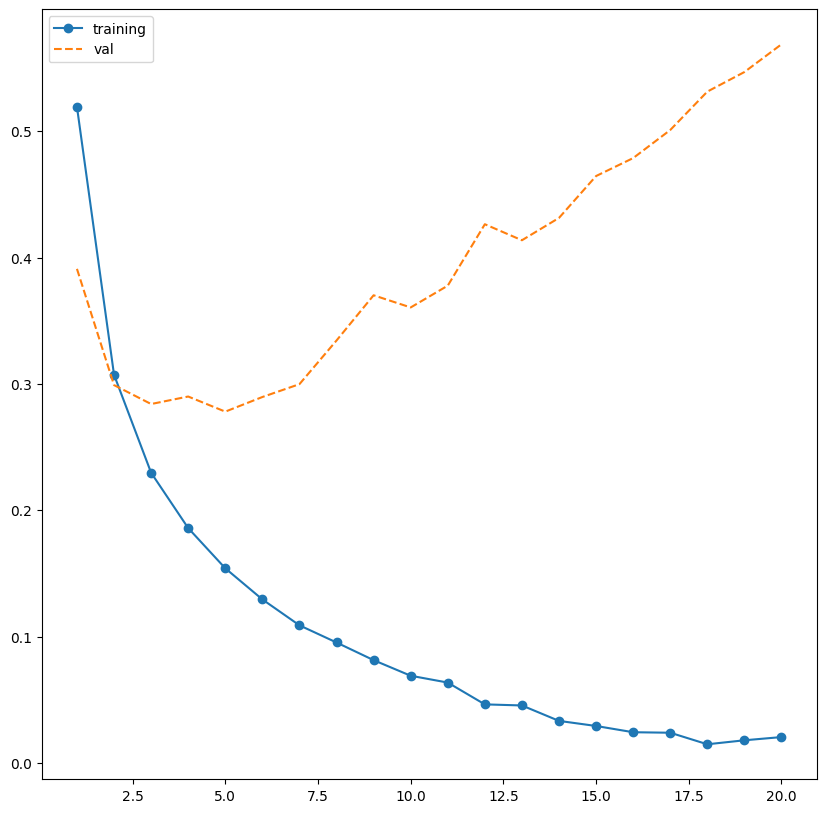

In [33]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='val')
plt.legend()
plt.show()

In [17]:
model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8597 - loss: 0.6208


[0.6208114624023438, 0.8596799969673157]

### Comparando con un modelo más pequeño

In [18]:
model2 = models.Sequential()
model2.add(layers.Dense(4, activation='relu', input_shape=(10000,)))
model2.add(layers.Dense(4, activation='relu'))
model2.add(layers.Dense(1, activation='sigmoid'))

In [19]:
model2.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [20]:
modelb2 = model2.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.6666 - loss: 0.6421 - val_accuracy: 0.8349 - val_loss: 0.5964
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8078 - loss: 0.5432 - val_accuracy: 0.8091 - val_loss: 0.5260
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8673 - loss: 0.4724 - val_accuracy: 0.8288 - val_loss: 0.4729
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - accuracy: 0.9007 - loss: 0.4056 - val_accuracy: 0.8769 - val_loss: 0.4138
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9219 - loss: 0.3434 - val_accuracy: 0.8884 - val_loss: 0.3679
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9326 - loss: 0.2914 - val_accuracy: 0.8881 - val_loss: 0.3323
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9379 - loss: 0.2520 - val_accuracy: 0.8886 - val_loss: 0.3086
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9435 - loss: 0.2223 - val_accuracy: 0.8826 - 

## Analizamos resultados

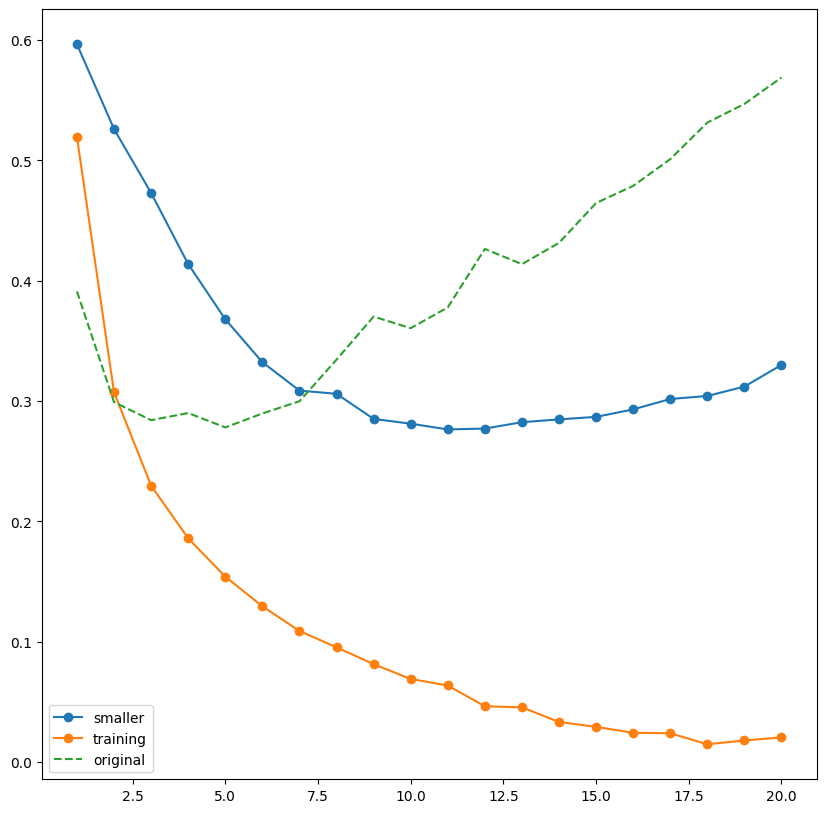

In [35]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values2 = modelb2.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values2, 'o-',label='smaller')
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

## Regularización

In [22]:
from keras import regularizers

In [23]:
model3 = models.Sequential()
model3.add(layers.Dense(16, activation='relu', input_shape=(10000,),kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(16, activation='relu',kernel_regularizer=regularizers.l2(0.001)))
model3.add(layers.Dense(1, activation='sigmoid'))

In [24]:
model3.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [25]:
modelb3 = model3.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 11s 317ms/step - accuracy: 0.7782 - loss: 0.5876 - val_accuracy: 0.8637 - val_loss: 0.4550
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8856 - loss: 0.3889 - val_accuracy: 0.8789 - val_loss: 0.3782
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9104 - loss: 0.3130 - val_accuracy: 0.8800 - val_loss: 0.3567
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9257 - loss: 0.2727 - val_accuracy: 0.8885 - val_loss: 0.3305
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9357 - loss: 0.2474 - val_accuracy: 0.8852 - val_loss: 0.3361
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9419 - loss: 0.2284 - val_accuracy: 0.8860 - val_loss: 0.3399
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9498 - loss: 0.2152 - val_accuracy: 0.8858 - val_loss: 0.3403
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.9553 - loss: 0.2021 - val_accuracy: 0.8790 -

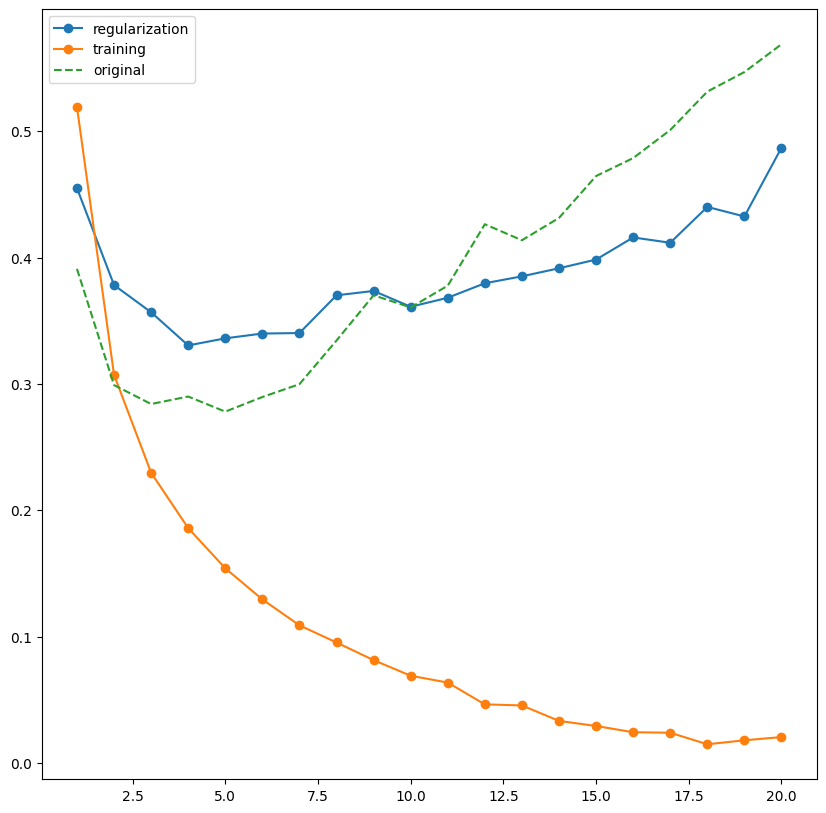

In [36]:
import matplotlib.pyplot as plt

modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values3 = modelb3.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values3, 'o-',label='regularization')
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

### Dropout

In [42]:
model4 = models.Sequential()
model4.add(layers.Dense(16, activation='relu', input_shape=(10000,)))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(16, activation='relu'))
model4.add(layers.Dropout(0.5))
model4.add(layers.Dense(1, activation='sigmoid'))

In [43]:
model4.compile(optimizer='rmsprop',
              loss='binary_crossentropy',
             metrics=['accuracy'])

In [44]:
modelb4 = model4.fit(partial_x_train,
                   partial_y_train,
                   epochs=20,
                   batch_size=512,
                   validation_data=(x_val,y_val))

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 144ms/step - accuracy: 0.6518 - loss: 0.6218 - val_accuracy: 0.8314 - val_loss: 0.5021
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step - accuracy: 0.7719 - loss: 0.5023 - val_accuracy: 0.8669 - val_loss: 0.4066
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 40ms/step - accuracy: 0.8303 - loss: 0.4242 - val_accuracy: 0.8820 - val_loss: 0.3300
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8637 - loss: 0.3601 - val_accuracy: 0.8863 - val_loss: 0.2977
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8849 - loss: 0.3114 - val_accuracy: 0.8878 - val_loss: 0.2784
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9032 - loss: 0.2662 - val_accuracy: 0.8870 - val_loss: 0.2848
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - accuracy: 0.9181 - loss: 0.2366 - val_accuracy: 0.8870 - val_loss: 0.2763
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9279 - loss: 0.2108 - val_accuracy: 0.8855 - 

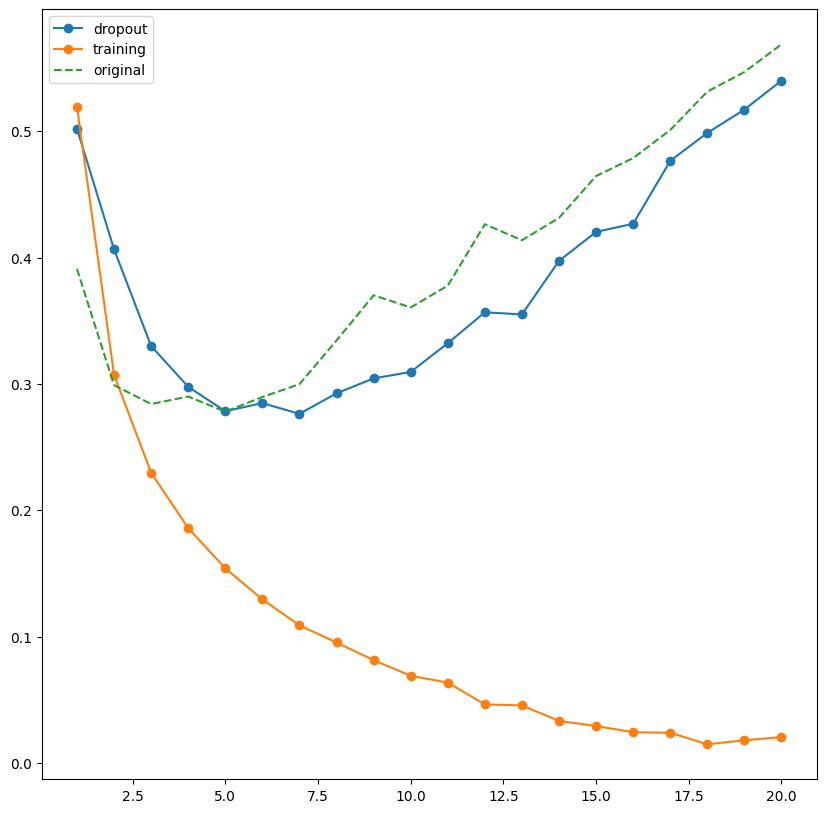

In [45]:
modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values4 = modelb4.history['val_loss']


fig = plt.figure(figsize=(10,10))
epoch = range(1,len(loss_values)+1)
plt.plot(epoch,val_loss_values4, 'o-',label='dropout')
plt.plot(epoch,loss_values, 'o-',label='training')
plt.plot(epoch,val_loss_values, '--',label='original')
plt.legend()
plt.show()

## Predicciones

In [46]:
predictions = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [47]:
predictions[10]

array([0.9923392], dtype=float32)

Epoch 1/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 7s 73ms/step - accuracy: 0.7187 - loss: 0.7597 - val_accuracy: 0.8665 - val_loss: 0.5584
Epoch 2/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.8295 - loss: 0.5379 - val_accuracy: 0.8776 - val_loss: 0.4650
Epoch 3/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8590 - loss: 0.4765 - val_accuracy: 0.8731 - val_loss: 0.4425
Epoch 4/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8754 - loss: 0.4394 - val_accuracy: 0.8804 - val_loss: 0.4146
Epoch 5/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8868 - loss: 0.4134 - val_accuracy: 0.8817 - val_loss: 0.4018
Epoch 6/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8940 - loss: 0.3984 - val_accuracy: 0.8814 - val_loss: 0.4017
Epoch 7/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9016 - loss: 0.3829 - val_accuracy: 0.8738 - val_loss: 0.4146
Epoch 8/20
59/59 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9059 - loss: 0.3777 - val_accuracy: 0.8806 - v

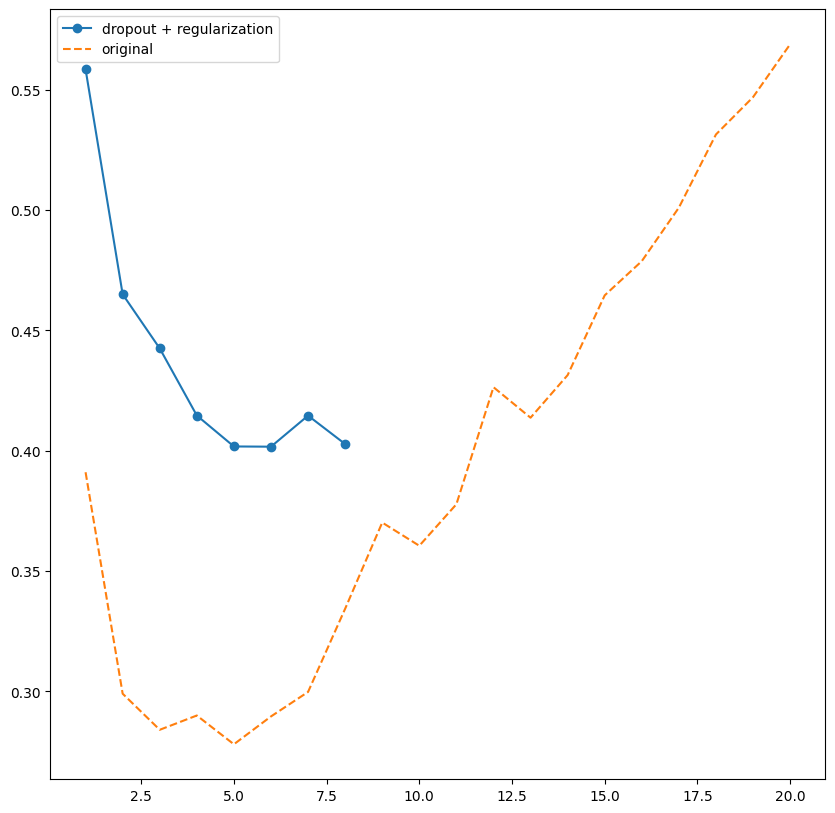

In [55]:
from keras import Input, callbacks

model4 = models.Sequential()
model4.add(Input(shape=(10000,)))

# Regularización combinada (16 redes neuronales)
model4.add(layers.Dense(
    16,
    activation='relu',
    kernel_regularizer=regularizers.l1_l2(l1=0.0002, l2=0.0005)
))
model4.add(layers.Dropout(0.25))  # ajuste a 0.5

model4.add(layers.Dense(
    8,
    activation='relu',
    kernel_regularizer=regularizers.l1_l2(l1=0.0002, l2=0.0005)
))
model4.add(layers.Dropout(0.25))  # ajuste 0.5

model4.add(layers.Dense(1, activation='sigmoid'))

model4.compile(
    optimizer='rmsprop',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping  alinea train vs val)
early_stop = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

modelb4 = model4.fit(
    partial_x_train,
    partial_y_train,
    epochs=20,
    batch_size=256,  # ajuste 512
    validation_data=(x_val, y_val),
    callbacks=[early_stop]
)

#  Comparación
modelb_dict = modelb.history
loss_values = modelb_dict['loss']
val_loss_values = modelb_dict['val_loss']

val_loss_values4 = modelb4.history['val_loss']

import matplotlib.pyplot as plt

# ORIGINAL
loss_values = modelb.history['loss']
val_loss_values = modelb.history['val_loss']
epochs_original = range(1, len(loss_values) + 1)

# NUEVO (con early stopping)
val_loss_values4 = modelb4.history['val_loss']
epochs_new = range(1, len(val_loss_values4) + 1)

fig = plt.figure(figsize=(10,10))

plt.plot(epochs_new, val_loss_values4, 'o-', label='dropout + regularization')
plt.plot(epochs_original, val_loss_values, '--', label='original')

plt.legend()
plt.show()

In [56]:
model.evaluate(x_test, y_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8597 - loss: 0.6208


[0.6208114624023438, 0.8596799969673157]

In [57]:
print("Épocas ejecutadas:", len(modelb4.history['loss']))

Épocas ejecutadas: 8


In [58]:
print("Épocas máximas configuradas: 20")
print("Épocas reales:", len(modelb4.history['loss']))

Épocas máximas configuradas: 20
Épocas reales: 8


In [59]:
best_epoch = np.argmin(modelb4.history['val_loss']) + 1
print("Mejor época (mínimo val_loss):", best_epoch)

Mejor época (mínimo val_loss): 6


Alreducir las redes neuronales baja el overfiting pero aumenta el loss. Además, Early Stopping detiene el entrenamiento en la época 8 (óptimo en 6) evidenciando ligero underfitting.